# Customer Intelligence System — Step 3: Segmentation
1. **Baseline:** classic RFM scoring (rule-based, what businesses have used for decades)
2. **K-Means** on recency + log(frequency) + log(monetary), scaled
3. **DBSCAN** to flag unusual customers (e.g. wholesalers)
4. **Compare:** does K-Means give more useful groups than the rules?

In [19]:
# 3.1 Setup
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sys.path.insert(0, str(Path("../src").resolve()))
from segmentation import rfm_scores, seg_matrix, SEG_FEATURES

PROC   = Path("../data/processed")
MODELS = Path("../models"); MODELS.mkdir(exist_ok=True)
profiles = pd.read_parquet(PROC / "customers_current.parquet")
pd.set_option("display.float_format", "{:,.1f}".format)
print("customers:", len(profiles))

customers: 5839


## A. Baseline: classic RFM scoring

In [20]:
# 3.2 RFM scores (1-5) and rule-based segments
rfm = rfm_scores(profiles)
profiles = profiles.join(rfm)

def seg_summary(df, col):
    s = df.groupby(col).agg(
        customers=("frequency", "size"),
        recency=("recency_days", "median"),
        orders=("frequency", "median"),
        spend=("monetary", "median"),
        revenue=("monetary", "sum"),
    )
    s["% customers"] = 100 * s["customers"] / s["customers"].sum()
    s["% revenue"]   = 100 * s["revenue"] / s["revenue"].sum()
    return s.drop(columns="revenue").sort_values("% revenue", ascending=False)

seg_summary(profiles, "rfm_segment")

,customers,recency,orders,spend,% customers,% revenue
rfm_segment,,,,,,
Champions,829,8.0,11.0,"3,889.4",14.2,52.2
Loyal,1154,52.0,8.0,"2,439.8",19.8,28.1
At Risk,752,376.0,3.0,920.6,12.9,5.7
Hibernating,1511,432.0,1.0,270.5,25.9,3.9
Potential Loyalists,704,23.0,3.0,668.5,12.1,3.7
Can't Lose,73,311.0,11.0,"3,574.7",1.3,3.0
Need Attention,268,106.0,3.0,923.5,4.6,1.8
About to Sleep,380,92.0,1.0,358.3,6.5,1.2
Promising,115,37.0,1.0,222.0,2.0,0.2


## B. K-Means

In [21]:
# 3.3 Build + scale the matrix
X = seg_matrix(profiles)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("matrix:", X_scaled.shape, "| means ~0:", X_scaled.mean(0).round(2), "| stds ~1:", X_scaled.std(0).round(2))

matrix: (5839, 3) | means ~0: [-0. -0. -0.] | stds ~1: [1. 1. 1.]


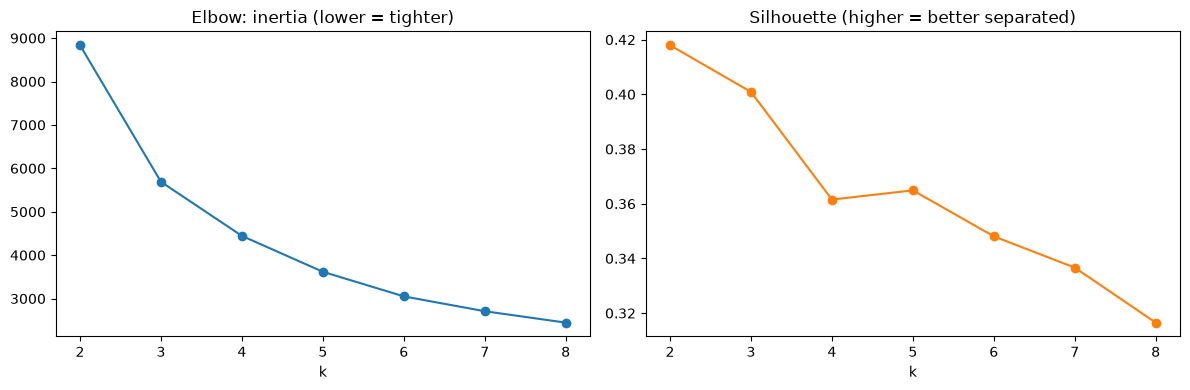

k=2  silhouette=0.418
k=3  silhouette=0.401
k=4  silhouette=0.362
k=5  silhouette=0.365
k=6  silhouette=0.348
k=7  silhouette=0.337
k=8  silhouette=0.317


In [22]:
# 3.4 Choose k: elbow (inertia) + silhouette
ks = range(2, 9)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ks, inertias, "o-"); ax[0].set_title("Elbow: inertia (lower = tighter)"); ax[0].set_xlabel("k")
ax[1].plot(ks, sils, "o-", color="tab:orange"); ax[1].set_title("Silhouette (higher = better separated)"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()
for k, s in zip(ks, sils): print(f"k={k}  silhouette={s:.3f}")

In [23]:
# 3.5 Fit final K-Means
# Pick K from 3.4: the best trade-off between silhouette and business usefulness
# (2 clusters = too coarse to act on; 7+ = too many for a marketing team).
K = 5
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X_scaled)
profiles["cluster"] = kmeans.labels_
seg_summary(profiles, "cluster")

,customers,recency,orders,spend,% customers,% revenue
cluster,,,,,,
4,868,17.0,16.0,"6,333.3",14.9,68.6
1,1692,42.0,5.0,"1,630.1",29.0,20.1
3,845,390.0,3.0,902.1,14.5,6.3
2,1357,65.0,2.0,358.6,23.2,3.4
0,1077,512.0,1.0,217.7,18.4,1.6


In [24]:
# 3.6 Name the clusters (fill in after reading the 3.5 table, then re-run)
# e.g. {0: "Champions", 1: "At-Risk Regulars", 2: "Lost / One-time", 3: "New & Promising"}
SEGMENT_NAMES = {4: "Champions", 1: "Loyal Regulars", 3: "Lapsed Regulars",
                 2: "New & Occasional", 0: "Lost One-timers"}

profiles["segment"] = profiles["cluster"].map(SEGMENT_NAMES).fillna(
    "Cluster " + profiles["cluster"].astype(str))
seg_summary(profiles, "segment")

,customers,recency,orders,spend,% customers,% revenue
segment,,,,,,
Champions,868,17.0,16.0,"6,333.3",14.9,68.6
Loyal Regulars,1692,42.0,5.0,"1,630.1",29.0,20.1
Lapsed Regulars,845,390.0,3.0,902.1,14.5,6.3
New & Occasional,1357,65.0,2.0,358.6,23.2,3.4
Lost One-timers,1077,512.0,1.0,217.7,18.4,1.6


## C. DBSCAN: who doesn't fit any group?

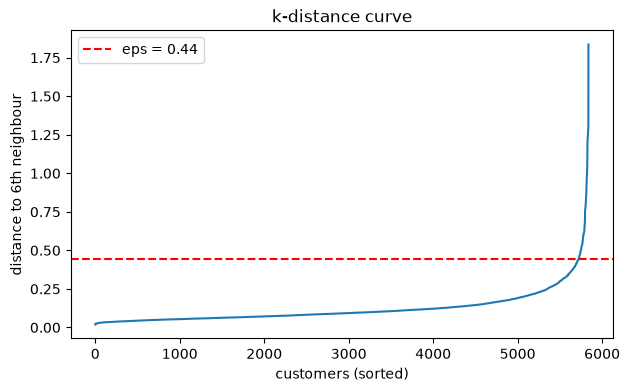

In [25]:
# 3.7 Pick eps from the k-distance curve
# For each customer: distance to its MIN_SAMPLES-th nearest neighbour.
# Dense customers have small distances; the sharp rise at the right = unusual customers.
MIN_SAMPLES = 6   # rule of thumb: 2 x number of features
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
kdist = np.sort(nn.kneighbors(X_scaled)[0][:, -1])

EPS = float(np.quantile(kdist, 0.98))   # start point: top ~2% most isolated
plt.figure(figsize=(7, 4))
plt.plot(kdist); plt.axhline(EPS, color="red", ls="--", label=f"eps = {EPS:.2f}")
plt.title("k-distance curve"); plt.xlabel("customers (sorted)"); plt.ylabel(f"distance to {MIN_SAMPLES}th neighbour")
plt.legend(); plt.show()

In [26]:
# 3.8 Run DBSCAN, inspect the outliers (label -1)
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(X_scaled)
profiles["is_outlier"] = (db.labels_ == -1).astype(int)

n_out = profiles["is_outlier"].sum()
print(f"DBSCAN groups: {len(set(db.labels_) - {-1})} | outliers: {n_out} ({n_out/len(profiles):.1%})")
print(f"Outliers' share of revenue: {profiles.loc[profiles.is_outlier == 1, 'monetary'].sum() / profiles['monetary'].sum():.1%}")

cols = ["recency_days", "frequency", "monetary", "avg_order_value", "is_uk"]
print("\nMedians: outliers vs everyone else")
display(profiles.groupby("is_outlier")[cols].median())
print("\nTop outliers by spend:")
display(profiles[profiles.is_outlier == 1].sort_values("monetary", ascending=False)[cols + ["segment"]].head(10))

DBSCAN groups: 2 | outliers: 58 (1.0%)
Outliers' share of revenue: 19.5%

Medians: outliers vs everyone else


,recency_days,frequency,monetary,avg_order_value,is_uk
is_outlier,,,,,
0,94.0,3.0,845.8,274.9,1.0
1,363.0,6.0,"9,457.3",554.8,1.0



Top outliers by spend:


,recency_days,frequency,monetary,avg_order_value,is_uk,segment
Customer ID,,,,,,
18102,0,145,"579,128.6","3,994.0",1,Champions
14646,1,143,"523,361.3","3,659.9",0,Champions
14156,9,143,"298,378.8","2,086.6",0,Champions
14911,1,369,"259,839.1",704.2,0,Champions
17450,8,49,"233,675.9","4,768.9",1,Champions
13694,3,141,"191,233.1","1,356.3",1,Champions
17511,2,59,"169,626.9","2,875.0",1,Champions
12415,24,23,"143,275.7","6,229.4",0,Champions
15311,0,205,"113,030.9",551.4,1,Champions


In [30]:
# 3.8b Key accounts = unusual AND top-5% spend; segment then tells active vs lapsed
top5 = profiles["monetary"] >= profiles["monetary"].quantile(0.95)
profiles["key_account"] = ((profiles["is_outlier"] == 1) & top5).astype(int)
print("Key accounts:", profiles["key_account"].sum())
display(profiles[profiles.key_account == 1]["segment"].value_counts())

Key accounts: 31


segment
Champions          22
Lapsed Regulars     5
Loyal Regulars      4
Name: count, dtype: int64

## D. Compare + visualise

In [31]:
# 3.9 Baseline vs K-Means
# Silhouette of BOTH labelings in the same feature space (note: K-Means optimises distance
# directly, so it has a built-in advantage here - business usefulness matters too).
print(f"Silhouette  RFM rules ({profiles.rfm_segment.nunique()} segs): {silhouette_score(X_scaled, profiles['rfm_segment']):.3f}")
print(f"Silhouette  K-Means   ({K} segs): {silhouette_score(X_scaled, profiles['cluster']):.3f}")

print("\nHow RFM segments map onto K-Means segments (% of each RFM segment):")
display((pd.crosstab(profiles["rfm_segment"], profiles["segment"], normalize="index") * 100).round(0))

Silhouette  RFM rules (10 segs): 0.058
Silhouette  K-Means   (5 segs): 0.365

How RFM segments map onto K-Means segments (% of each RFM segment):


segment,Champions,Lapsed Regulars,Lost One-timers,Loyal Regulars,New & Occasional
rfm_segment,,,,,
About to Sleep,0.0,0.0,0.0,6.0,94.0
At Risk,0.0,75.0,9.0,12.0,4.0
Can't Lose,52.0,27.0,0.0,21.0,0.0
Champions,56.0,0.0,0.0,44.0,0.0
Hibernating,0.0,17.0,67.0,0.0,15.0
Loyal,32.0,0.0,0.0,66.0,2.0
Need Attention,0.0,0.0,0.0,60.0,40.0
New Customers,0.0,0.0,0.0,2.0,98.0
Potential Loyalists,0.0,0.0,0.0,38.0,62.0


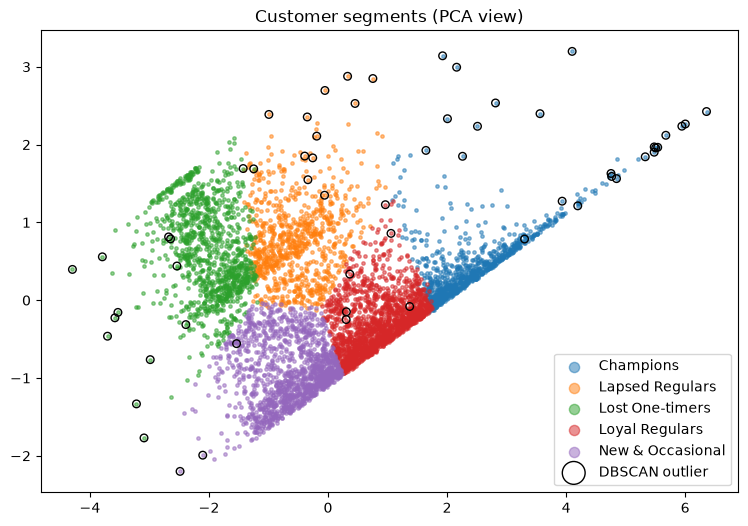

In [32]:
# 3.10 2-D picture (PCA squashes 3 features into 2 axes for plotting only)
pts = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(9, 6))
for seg in sorted(profiles["segment"].unique()):
    m = (profiles["segment"] == seg).to_numpy()
    plt.scatter(pts[m, 0], pts[m, 1], s=6, alpha=0.5, label=seg)
o = (profiles["is_outlier"] == 1).to_numpy()
plt.scatter(pts[o, 0], pts[o, 1], s=30, facecolors="none", edgecolors="black", label="DBSCAN outlier")
plt.legend(markerscale=3); plt.title("Customer segments (PCA view)"); plt.show()

In [33]:
# 3.11 Save segmented customers + fitted models (the app reuses these)
profiles.to_parquet(PROC / "customers_segmented.parquet")
joblib.dump({"scaler": scaler, "kmeans": kmeans, "segment_names": SEGMENT_NAMES}, MODELS / "segmentation.joblib")
print("saved:", profiles.shape, "+ models/segmentation.joblib")

saved: (5839, 28) + models/segmentation.joblib
